# Temporal · multi-field — pipeline demo template

The **temporal multi-field** template.  Every demo in this group follows the same three steps — **load → run → plot** — all driven by [`nb_support.py`](../nb_support.py):

1. **Load** a theory from `theories/<name>.theory.py` (the single source of truth — no inline model building).
2. **Run** it with one `nb.Config(...)`: the correlator order `k`, the loop order `max_ell`, the Dyson order, the grids, and every plotting option live there.
3. **Plot** with `nb.plot_cumulant`, which auto-dispatches to the form natural to this group.

This template ships with **`ou_quartic_two_dim`**.  To demo a different temporal theory, set `THEORY` below to any multi-field/multi-population temporal `theories/*.theory.py` (e.g. `ou_quartic_two_dim_corr`, `multipopulation_test`).  Everything else is identical across all four group templates on purpose — common thematics for the demos.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import nb_support as nb
print('nb_support \u2192', nb.REPO_ROOT)

nb_support → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Choose the theory & configure the run

This is the only cell you edit.  `k` and `max_ell` are free (arbitrary correlator order and loop order); the plotting options (`show_orders`, `logy`, `figsize`, …) are adaptable.

In [2]:
THEORY = 'ou_quartic_two_dim'   # any multi-field temporal theory

cfg = nb.Config(
    k=2,
    max_ell=0,      # tree; bump to 1 for the 1-loop correction
    # Multi-field: choose which legs to correlate.  None → auto
    # ⟨field0 field0⟩.  For the cross-correlator ⟨xy⟩:
    # external_fields=[('dx', 1), ('dy', 1)],

    tau_max=8.0,
    tau_step=0.5,

    show_orders='cumulative',
    logy=False,
)

In [3]:
model, mod = nb.load_theory(THEORY)
print('loaded :', model.get('name'))
print('fields :', nb.field_names(model),
      '| spatial_dim:', nb.spatial_dim(model),
      '| multi-field:', nb.is_multifield(model))
print('params :', [p['name'] for p in (model.get('parameters') or [])])

loaded : OU Quartic Two Dim
fields : ['dx', 'dy'] | spatial_dim: 0 | multi-field: True
params : ['xstar', 'ystar', 'mu1', 'mu2', 'eps1', 'eps2', 'J1', 'J2', 'D1', 'D2']


## 3. Run

In [4]:
res = nb.run(model, cfg, mod)
print(nb.summary(res))

theory : 'OU Quartic Two Dim'
k      : 2    max_ell : 0
fields : ['dx', 'dy']   spatial_dim : 0


## 4. Plot

`show_orders` controls the per-loop-order overlay: `'cumulative'` (tree, tree+1-loop, …), `'incremental'` (each order alone), or `'total'` (the summed result only).

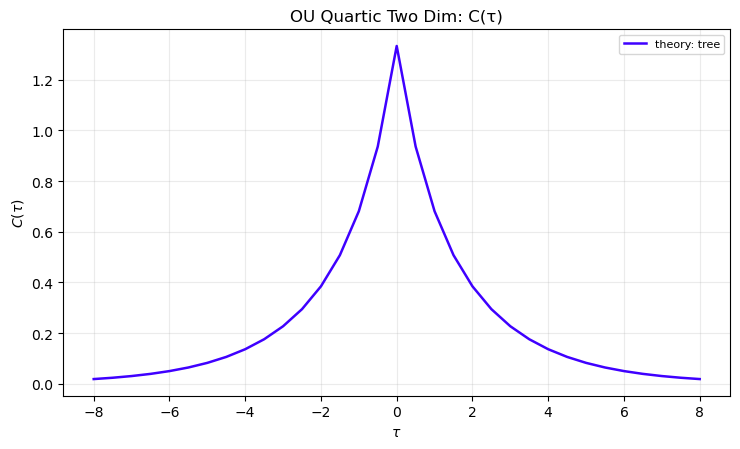

In [5]:
fig = nb.plot_cumulant(res, cfg, model)
plt.show()